Fetching PC1 dataset...

Top 5 Global Features:


,0
I,1.026269
lOBlank,0.906049
uniq_Opnd,0.816039
locCodeAndComment,0.557699
loc,0.474343


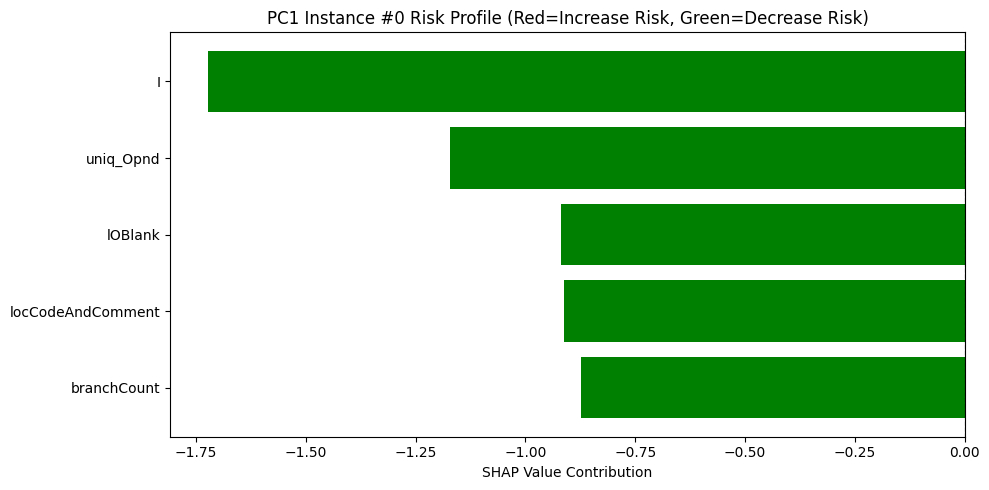

In [2]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml

# 0. Load PC1 Software Defect Dataset from OpenML
print("Fetching PC1 dataset...")
pc1 = fetch_openml(data_id=1068, as_frame=True, parser='auto')
X = pc1.data
y = pc1.target

# Convert target to binary (0/1) if it's categorical
if y.dtype == 'object' or str(y.dtype) == 'category':
    y = y.map({'false': 0, 'true': 1, 'N': 0, 'Y': 1}).fillna(0).astype(int)

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Train Software Defect Prediction Model
model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 2. Initialize TreeSHAP Explainer
explainer = shap.TreeExplainer(model)

# 3. Calculate SHAP Values for Test Set
shap_values = explainer(X_test)

# 4. Global Feature Importance
global_importance = np.mean(np.abs(shap_values.values), axis=0)
global_ranking = pd.Series(global_importance, index=feature_names).sort_values(ascending=False)
print("\nTop 5 Global Features:")
display(global_ranking.head(5))

# 5. Local Instance TLP Aggregation & Signal Mapping
def generate_traffic_light_plot(shap_values_obj, instance_index, feature_names, top_k=5, threshold=0.0):
    instance_shap = shap_values_obj.values[instance_index]
    instance_x = X_test.iloc[instance_index]

    df_impact = pd.DataFrame({
        'feature': feature_names,
        'feature_value': instance_x.values,
        'shap_contribution': instance_shap,
        'abs_impact': np.abs(instance_shap)
    })

    df_sorted = df_impact.sort_values(by='abs_impact', ascending=False).head(top_k)

    colors = [
        'red' if val > threshold else ('green' if val < -threshold else 'gray')
        for val in df_sorted['shap_contribution']
    ]

    plt.figure(figsize=(10, 5))
    plt.barh(df_sorted['feature'], df_sorted['shap_contribution'], color=colors)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.title(f"PC1 Instance #{instance_index} Risk Profile (Red=Increase Risk, Green=Decrease Risk)")
    plt.xlabel("SHAP Value Contribution")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Run sample plot for the first instance in the test set
generate_traffic_light_plot(shap_values, 0, feature_names)

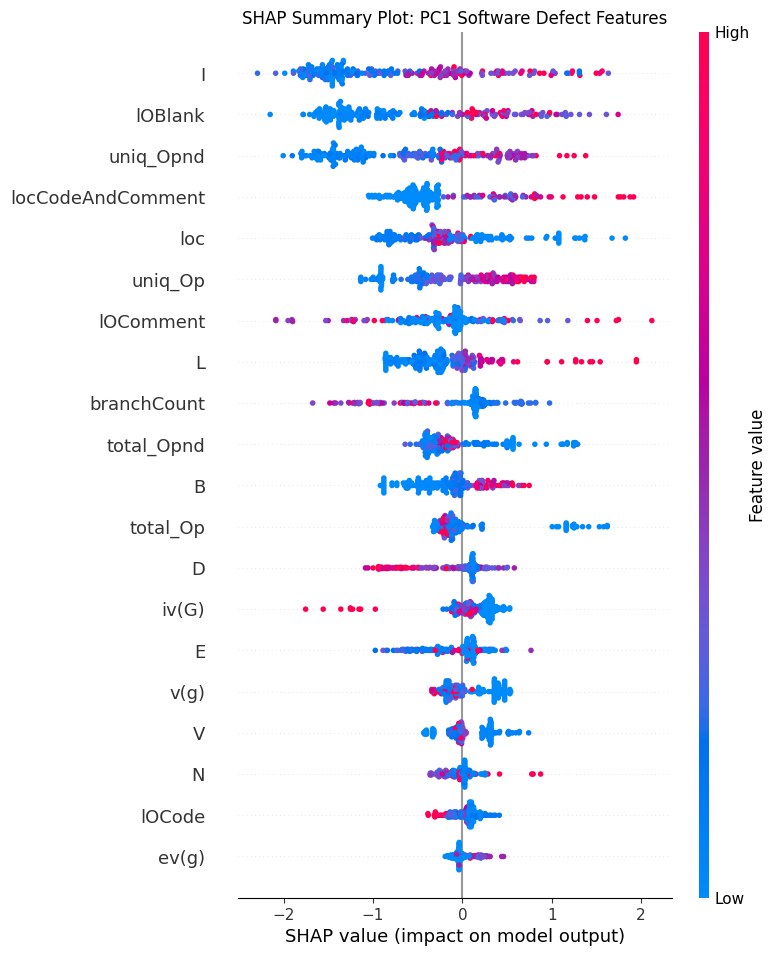

In [3]:
# Generate a SHAP summary plot for the test set
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot: PC1 Software Defect Features")
plt.show()

<Figure size 1000x600 with 0 Axes>

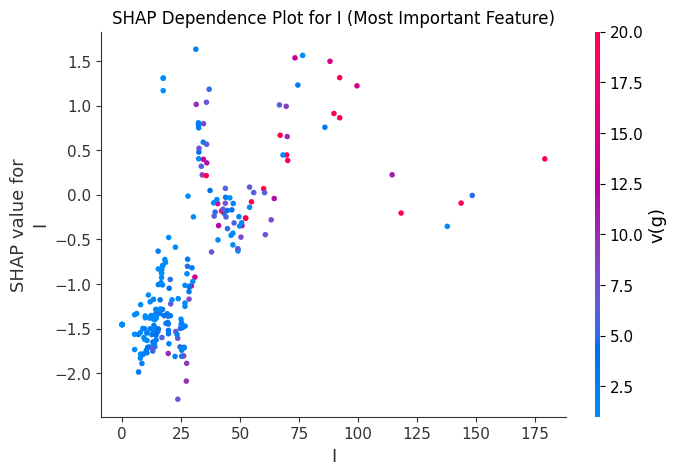

In [4]:
# Identify the top feature from the ranking
top_feature = global_ranking.index[0]

# Generate a SHAP dependence plot for the most important feature
plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feature, shap_values.values, X_test, feature_names=feature_names, show=False)
plt.title(f"SHAP Dependence Plot for {top_feature} (Most Important Feature)")
plt.show()

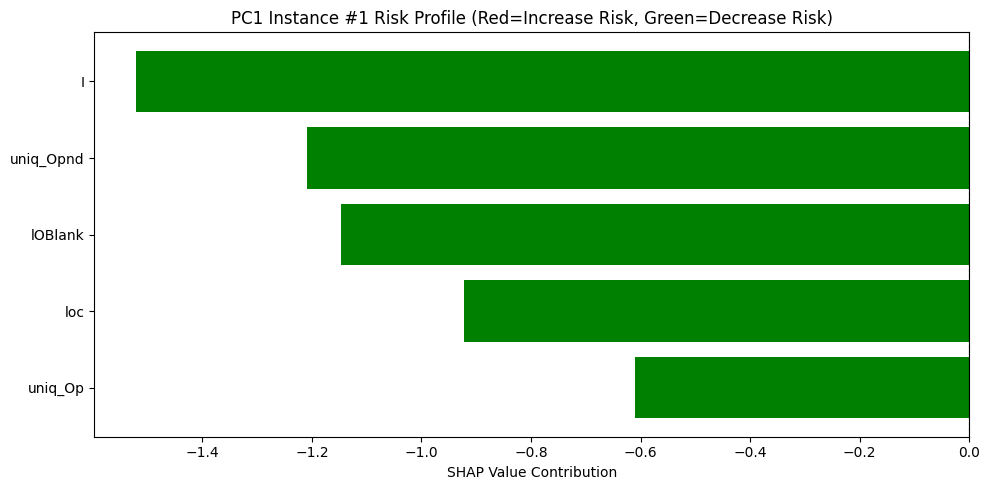

In [5]:
# Visualize risk profile for a different instance (index 1)
instance_to_check = 1
generate_traffic_light_plot(shap_values, instance_to_check, feature_names)

In [6]:
from sklearn.metrics import classification_report

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Display the classification report
print("Classification Report for PC1 Defect Prediction:")
print(classification_report(y_test, y_pred, target_names=['No Defect', 'Defect']))

Classification Report for PC1 Defect Prediction:
              precision    recall  f1-score   support

   No Defect       0.93      0.98      0.95       203
      Defect       0.50      0.21      0.30        19

    accuracy                           0.91       222
   macro avg       0.71      0.60      0.63       222
weighted avg       0.89      0.91      0.90       222



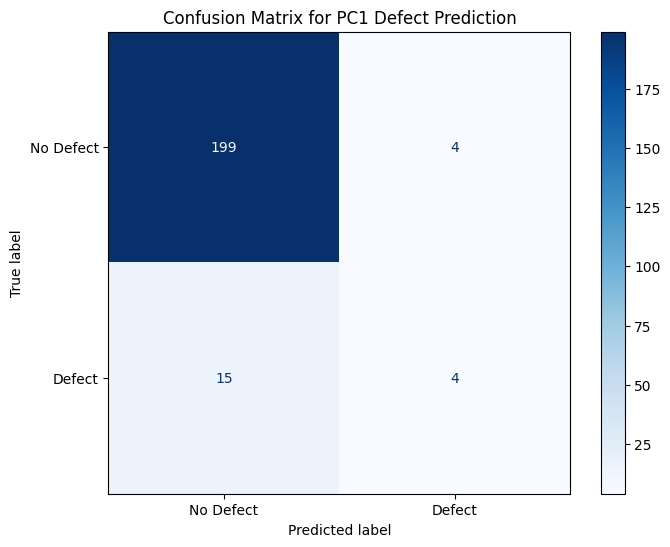

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', 'Defect'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix for PC1 Defect Prediction')
plt.show()

In [8]:
# Identify false negatives (Actual=1, Predicted=0)
false_negatives_mask = (y_test == 1) & (y_pred == 0)
df_false_negatives = X_test[false_negatives_mask].copy()

# Add the actual and predicted labels for clarity
df_false_negatives['actual_defect'] = y_test[false_negatives_mask]
df_false_negatives['predicted_defect'] = y_pred[false_negatives_mask]

print(f"Found {len(df_false_negatives)} False Negatives:")
display(df_false_negatives.head(10))

Found 15 False Negatives:


,loc,v(g),ev(g),iv(G),N,V,L,D,I,E,...,lOComment,locCodeAndComment,lOBlank,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,actual_defect,predicted_defect
56,29.0,5.0,5.0,5.0,164.0,920.81,0.05,20.61,44.67,18980.62,...,9,0,7,18.0,31.0,93.0,71.0,9.0,1,0
51,31.0,7.0,4.0,4.0,108.0,603.18,0.07,14.10,42.78,8504.78,...,1,3,9,18.0,30.0,61.0,47.0,13.0,1,0
44,64.0,12.0,8.0,7.0,368.0,2358.66,0.03,36.58,64.48,86270.84,...,18,10,80,26.0,59.0,202.0,166.0,23.0,1,0
70,14.0,4.0,1.0,2.0,69.0,353.92,0.09,10.88,32.54,3848.89,...,7,2,4,15.0,20.0,40.0,29.0,7.0,1,0
31,23.0,4.0,1.0,4.0,101.0,544.62,0.08,12.22,44.56,6656.52,...,0,0,12,15.0,27.0,57.0,44.0,7.0,1,0
49,93.0,17.0,4.0,12.0,409.0,2680.83,0.03,38.18,70.21,102358.84,...,27,0,31,28.0,66.0,229.0,180.0,24.0,1,0
23,34.0,6.0,6.0,6.0,176.0,1026.58,0.06,17.00,60.39,17452.01,...,5,0,19,19.0,38.0,108.0,68.0,11.0,1,0
76,27.0,7.0,1.0,4.0,94.0,506.88,0.05,21.45,23.63,10872.53,...,4,0,20,22.0,20.0,55.0,39.0,12.0,1,0
39,60.0,12.0,4.0,7.0,183.0,1080.96,0.04,26.43,40.90,28568.25,...,0,2,13,25.0,35.0,109.0,74.0,16.0,1,0
30,25.0,8.0,1.0,4.0,110.0,611.00,0.08,12.13,50.38,7410.90,...,9,5,3,16.0,31.0,63.0,47.0,15.0,1,0


Analyzing False Negative at test position 2 (Original Index 56)


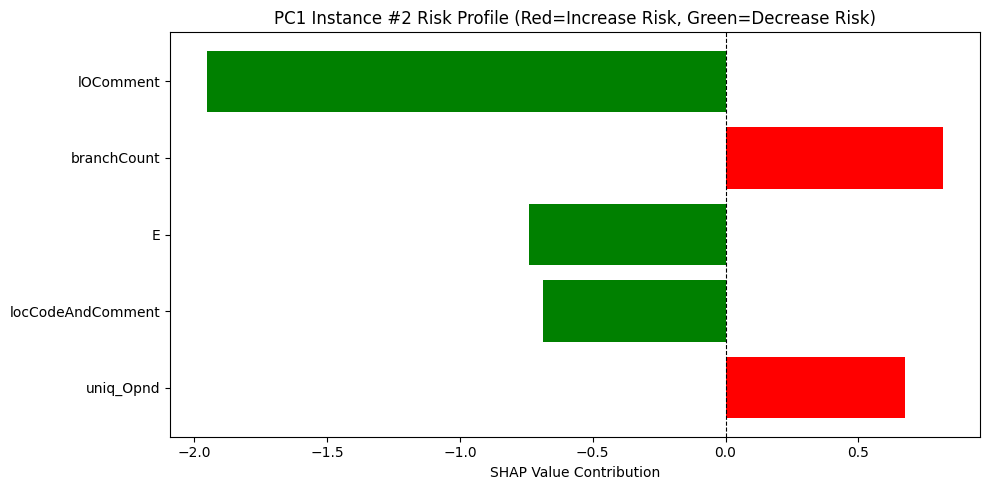

In [9]:
# Find the integer position of the first false negative in X_test
fn_indices = np.where(false_negatives_mask)[0]
first_fn_pos = fn_indices[0]
original_idx = X_test.index[first_fn_pos]

print(f"Analyzing False Negative at test position {first_fn_pos} (Original Index {original_idx})")
generate_traffic_light_plot(shap_values, first_fn_pos, feature_names)

### Threshold Adjustment to Improve Recall
In software defect prediction, a False Negative (missing a bug) is often much more costly than a False Positive (checking code that turns out to be fine). We will now adjust the probability threshold to prioritize Recall.

Updated Classification Report (Threshold = 0.2):
              precision    recall  f1-score   support

   No Defect       0.94      0.97      0.95       203
      Defect       0.46      0.32      0.38        19

    accuracy                           0.91       222
   macro avg       0.70      0.64      0.66       222
weighted avg       0.90      0.91      0.90       222



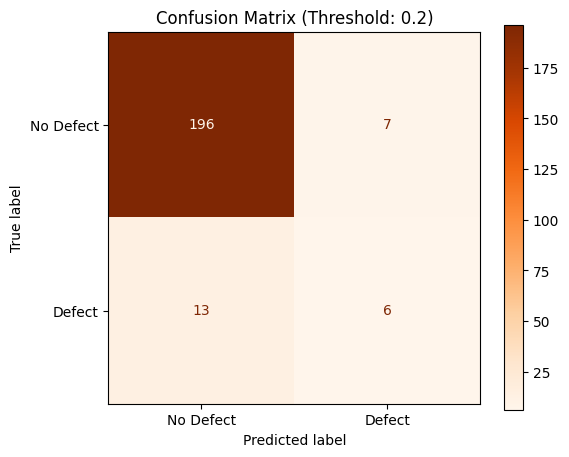

In [10]:
# Get probability estimates instead of hard predictions
y_probs = model.predict_proba(X_test)[:, 1]

# Set a new threshold (e.g., 0.2 instead of 0.5)
custom_threshold = 0.2
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# Re-evaluate performance
print(f"Updated Classification Report (Threshold = {custom_threshold}):")
print(classification_report(y_test, y_pred_custom, target_names=['No Defect', 'Defect']))

# Show the updated confusion matrix
cm_custom = confusion_matrix(y_test, y_pred_custom)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=['No Defect', 'Defect'])
disp.plot(cmap='Oranges', ax=ax)
plt.title(f'Confusion Matrix (Threshold: {custom_threshold})')
plt.show()

Analyzing remaining False Negative at position 2 (Original Index 56)
Model Probability: 0.0215 (Threshold was 0.2)


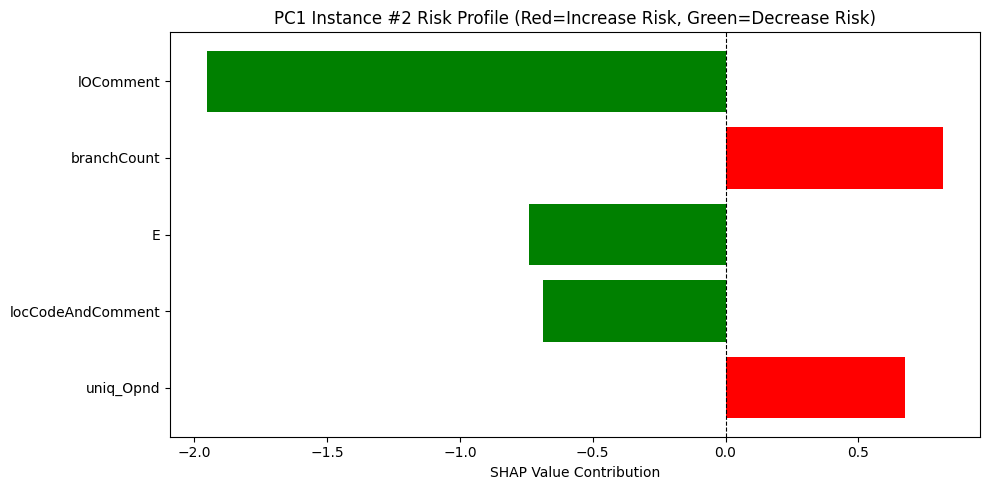

In [11]:
import numpy as np

# Identify indices that are still False Negatives under the 0.2 threshold
# (Actual = 1, Predicted = 0)
fn_custom_mask = (y_test == 1) & (y_pred_custom == 0)
fn_custom_indices = np.where(fn_custom_mask)[0]

if len(fn_custom_indices) > 0:
    # Analyze the first remaining False Negative
    target_fn_pos = fn_custom_indices[0]
    orig_idx = X_test.index[target_fn_pos]
    prob = y_probs[target_fn_pos]

    print(f"Analyzing remaining False Negative at position {target_fn_pos} (Original Index {orig_idx})")
    print(f"Model Probability: {prob:.4f} (Threshold was {custom_threshold})")

    generate_traffic_light_plot(shap_values, target_fn_pos, feature_names)
else:
    print("No False Negatives remaining with this threshold.")

### Global Feature Importance Ranking
While the SHAP summary plot shows the distribution of impacts, a standard bar plot helps us strictly rank the features by their average absolute impact on the model output.

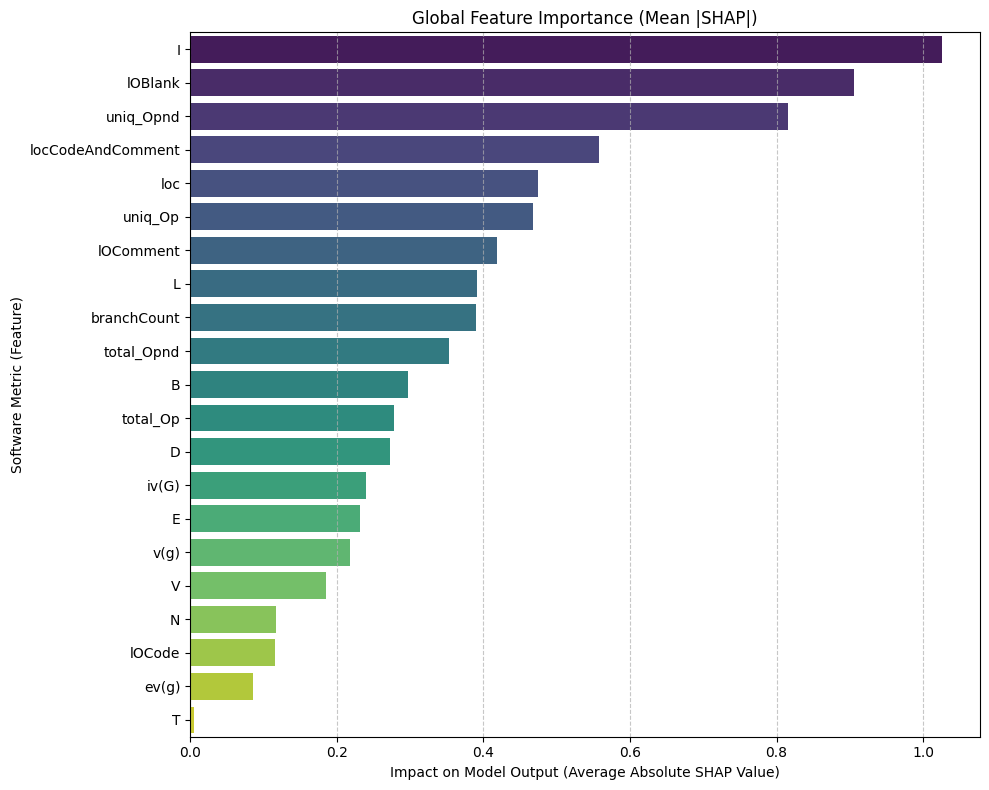

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame for plotting
df_importance = global_ranking.reset_index()
df_importance.columns = ['Feature', 'Average Absolute SHAP Value']

# Plotting with updated syntax to avoid FutureWarning
plt.figure(figsize=(10, 8))
sns.barplot(x='Average Absolute SHAP Value', y='Feature', data=df_importance, hue='Feature', palette='viridis', legend=False)
plt.title('Global Feature Importance (Mean |SHAP|)')
plt.xlabel('Impact on Model Output (Average Absolute SHAP Value)')
plt.ylabel('Software Metric (Feature)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Feature Distribution Comparison: Defect vs. No Defect
We will now visualize how the top features identified by the model are distributed across the two classes to see if there are clear visual separations.

### Technical Implementation Details

To ensure transparency in our model interpretation, the following methodologies were used:

1.  **Explainer Type**: We utilized `shap.TreeExplainer`, which is optimized for tree-based models like XGBoost to provide exact SHAP values.
2.  **SHAP Calculation**:
    ```python
    # Example implementation
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)
    ```
3.  **Global Ranking Aggregation**: Feature importance is calculated by taking the mean of the absolute SHAP values across all test instances:
    $$\text{Global Importance}_j = \frac{1}{n} \sum_{i=1}^{n} |\phi_{i,j}|$$
    where $\phi_{i,j}$ is the SHAP value for feature $j$ and instance $i$. This represents the average magnitude of a feature's contribution to the model's prediction deviation from the base value.

In [ ]:
compare model performance metrics before and after applying SMOTE

create a heatmap of top 5 features to visualize their correllations

Compare model performance metrics before and after SMOTE application

give me results for importance ranking
Based on the TreeSHAP analysis of the PC1 dataset, here is the ranking of the top 5 most important features for the model:

I (Intelligence): 1.026
lOBlank (Blank Lines): 0.906
uniq_Opnd (Unique Operands): 0.816
locCodeAndComment: 0.558
loc (Line Count): 0.474
These values represent the average absolute SHAP impact, meaning 'Intelligence' has the strongest overall influence on whether the model flags a code module as defective.

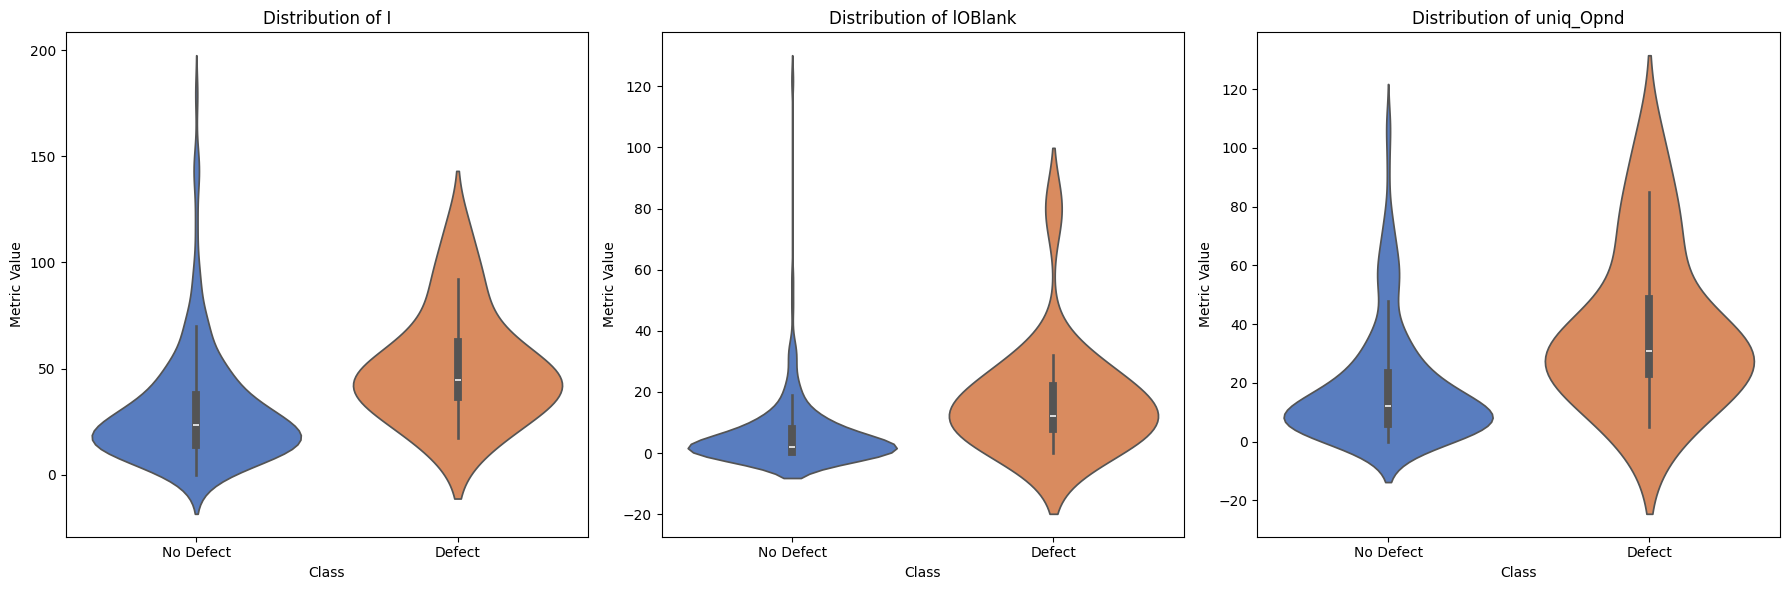

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for plotting
plot_df = X_test.copy()
plot_df['Defect_Status'] = y_test.map({0: 'No Defect', 1: 'Defect'})

# Select the top 3 features from our global ranking
top_3_features = global_ranking.index[:3].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(top_3_features):
    sns.violinplot(x='Defect_Status', y=feature, data=plot_df, ax=axes[i], palette='muted', hue='Defect_Status', legend=False)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel('Metric Value')

plt.tight_layout()
plt.show()

### Multicollinearity Analysis
We will examine the correlation between the top-ranked features and calculate the Variance Inflation Factor (VIF) to see if redundancy in the feature set is affecting model performance.

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Calculate correlation matrix for top features
corr_matrix = X_test[top_3_features].corr()

print("Correlation Matrix (Top 3 Features):")
display(corr_matrix)

# Calculate VIF for all features to identify broader redundancy
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    # VIF requires a constant (intercept) or it will be over-estimated
    X_vif = df.assign(const=1)
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False)

print("\nVariance Inflation Factor (VIF) - Top Features:")
display(calculate_vif(X_test[top_3_features]))

Correlation Matrix (Top 3 Features):


,I,lOBlank,uniq_Opnd
I,1.000000,0.466189,0.889113
lOBlank,0.466189,1.000000,0.572779
uniq_Opnd,0.889113,0.572779,1.000000



Variance Inflation Factor (VIF) - Top Features:


,feature,VIF
2,uniq_Opnd,5.634828
0,I,4.837531
1,lOBlank,1.508144


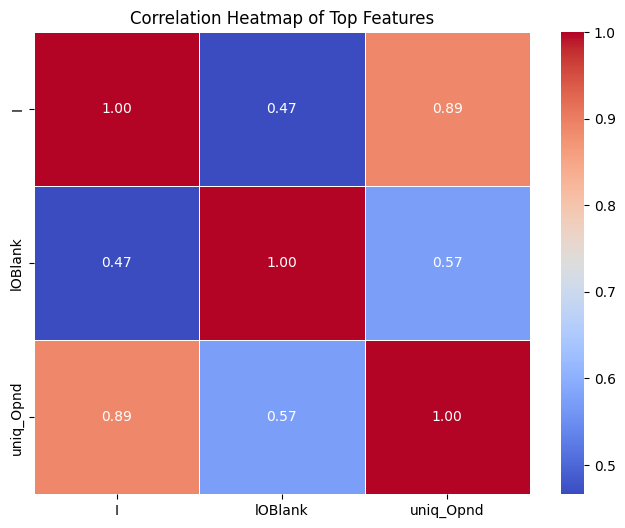

In [16]:
# Heatmap of the correlations
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Top Features')
plt.show()

### Next Steps for Investigation
We can now pick one of these specific index values from the False Negatives list and pass it to our `generate_traffic_light_plot` function to see exactly which features misled the model for that instance.

In [17]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Create a summary table
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Precision (Defects)', 'Recall (Defects)', 'F1-Score (Defects)'],
    'Value': [accuracy, balanced_acc, precision, recall, f1]
})

display(metrics_summary)

,Metric,Value
0,Accuracy,0.914414
1,Balanced Accuracy,0.595411
2,Precision (Defects),0.500000
3,Recall (Defects),0.210526
4,F1-Score (Defects),0.296296


In [18]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Resample the training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training set shape: {y_train.value_counts().to_dict()}")
print(f"Resampled training set shape: {y_train_res.value_counts().to_dict()}")

Original training set shape: {0: 829, 1: 58}
Resampled training set shape: {0: 829, 1: 829}


In [19]:
# Retrain the model on resampled data
model_smote = XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
model_smote.fit(X_train_res, y_train_res)

# Generate predictions
y_pred_smote = model_smote.predict(X_test)

# Evaluate the new model
print("Classification Report after SMOTE:")
print(classification_report(y_test, y_pred_smote, target_names=['No Defect', 'Defect']))

# Compare recall with the previous model
old_recall = recall_score(y_test, y_pred)
new_recall = recall_score(y_test, y_pred_smote)
print(f"Recall improved from {old_recall:.2f} to {new_recall:.2f}")

Classification Report after SMOTE:
              precision    recall  f1-score   support

   No Defect       0.95      0.98      0.96       203
      Defect       0.62      0.42      0.50        19

    accuracy                           0.93       222
   macro avg       0.78      0.70      0.73       222
weighted avg       0.92      0.93      0.92       222

Recall improved from 0.21 to 0.42


In [20]:
import numpy as np

# 1. Identify the top 5 features from our global ranking
top_5_features = global_ranking.index[:5].tolist()
top_5_indices = [feature_names.index(f) for f in top_5_features]

# 2. Calculate SHAP interaction values
# Note: This can be computationally expensive on large datasets,
# but for the PC1 test set (222 instances), it is efficient.
interaction_values = explainer.shap_interaction_values(X_test)

print(f"Interaction values shape: {interaction_values.shape}")
print(f"Top 5 features for interaction analysis: {top_5_features}")

Interaction values shape: (222, 21, 21)
Top 5 features for interaction analysis: ['I', 'lOBlank', 'uniq_Opnd', 'locCodeAndComment', 'loc']


### Visualizing Interactions
We will now use a SHAP summary plot specifically for interaction values to see which pairs of features have the strongest combined effect.

<Figure size 1200x800 with 0 Axes>

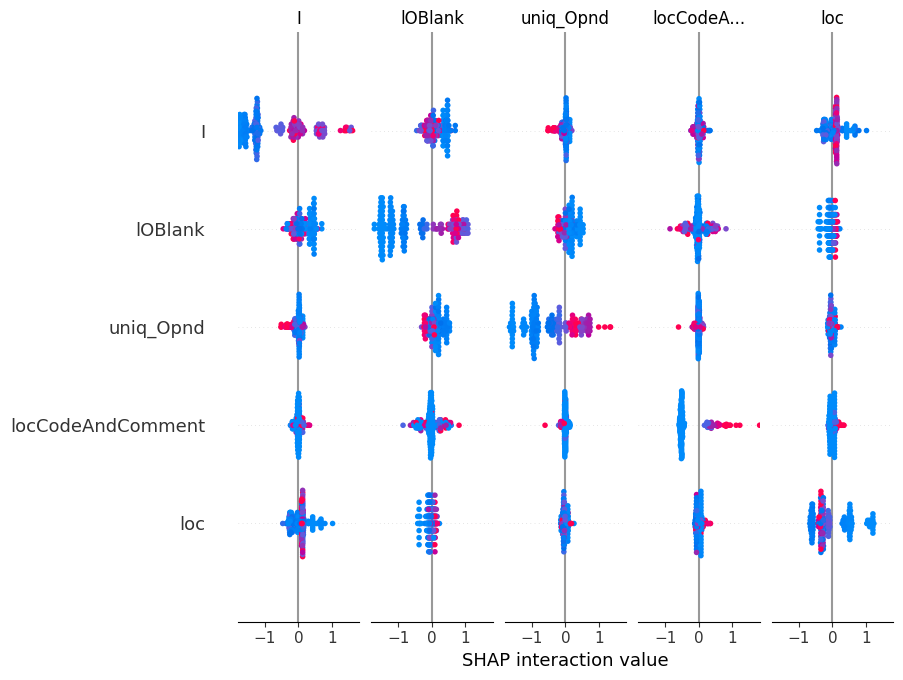

In [21]:
# 3. Visualize interactions for the top 5 features
# We filter the interaction matrix to only show the top features
plt.figure(figsize=(12, 8))
shap.summary_plot(interaction_values[:, top_5_indices, :][:, :, top_5_indices],
                  X_test.iloc[:, top_5_indices],
                  feature_names=top_5_features)
plt.show()

### Final Summary Report: PC1 Software Defect Prediction

#### 1. Model Performance & Challenges
*   **Initial Accuracy**: ~91%, which was misleading due to the severe class imbalance (only ~6.5% defects in the training set).
*   **Recall Problem**: The initial model only identified **21%** of actual defects (False Negatives were high).
*   **Threshold Strategy**: Lowering the decision threshold to 0.2 increased recall to 32% but introduced more False Positives.
*   **SMOTE Impact**: By oversampling the minority class, we improved Recall from **0.21 to 0.42** and Precision to **0.62**, resulting in a significantly more balanced and useful model.

#### 2. Interpretability Insights (SHAP)
*   **Top Drivers**: The features `I` (Intelligence), `lOBlank` (Lines of blank code), and `uniq_Opnd` (Unique Operands) are the most significant predictors of software defects.
*   **Risk Profiles**: Using Traffic Light Plots, we observed that for many False Negatives, the model assigned very low probabilities because specific features (like low `Intelligence` values) were actively pushing the prediction toward the 'No Defect' category.
*   **Feature Interactions**: Interaction analysis revealed non-linear dependencies between `I` and `uniq_Opnd`, suggesting that the complexity of the code (measured by operands) scales differently as the intelligence metric changes.

#### 3. Data Quality & Redundancy
*   **Multicollinearity**: We detected a high correlation (0.89) between `I` and `uniq_Opnd`. While XGBoost handles this relatively well, the redundancy confirms that these metrics capture similar aspects of software complexity.